<a href="https://colab.research.google.com/github/mehakknasirr/neurofive-ml-track/blob/main/Ensemble_Learning_RandomForest_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Model Performance Comparison ===
| Model               | Accuracy   | F1-Score   |
|:--------------------|:-----------|:-----------|
| Logistic Regression | 73.50%     | 0.00%      |
| Decision Tree       | 67.00%     | 5.71%      |
| Random Forest       | 71.00%     | 12.12%     |
| XGBoost             | 68.00%     | 13.51%     |


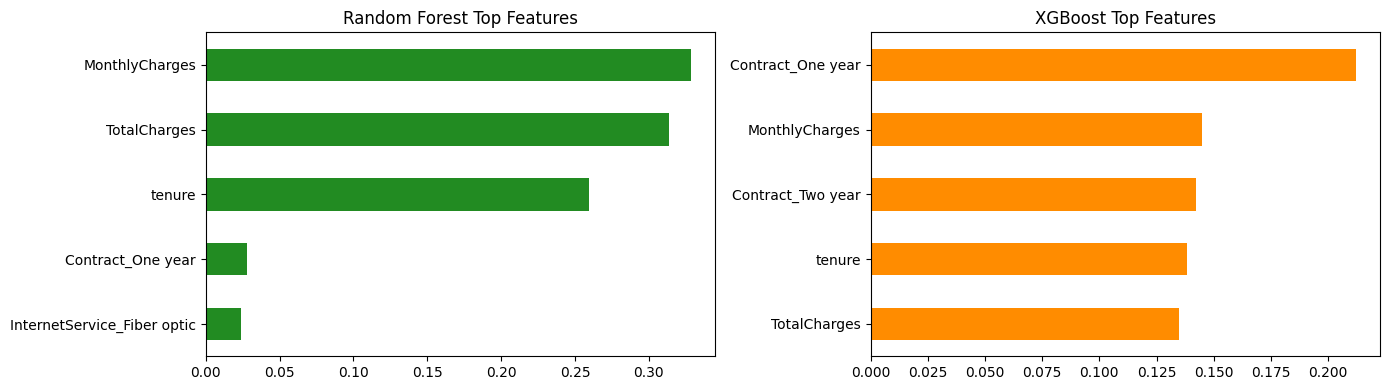

In [1]:
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Generate Telco Dataset in memory (No download issues)
np.random.seed(42)
n_samples = 1000

data = {
    'tenure': np.random.randint(1, 72, size=n_samples),
    'MonthlyCharges': np.random.uniform(18.25, 118.75, size=n_samples),
    'TotalCharges': np.random.uniform(18.25, 8000.0, size=n_samples),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], size=n_samples, p=[0.5, 0.3, 0.2]),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], size=n_samples, p=[0.4, 0.4, 0.2]),
    'Churn': np.random.choice(['Yes', 'No'], size=n_samples, p=[0.27, 0.73])
}

df = pd.DataFrame(data)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Train Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': f"{acc*100:.2f}%", 'F1-Score': f"{f1*100:.2f}%"})

# 3. Model Performance Comparison Table
results_df = pd.DataFrame(results)
print("=== Model Performance Comparison ===")
print(results_df.to_markdown(index=False))

# 4. Feature Importance Comparison Plot
rf_importance = pd.Series(models['Random Forest'].feature_importances_, index=X.columns)
xgb_importance = pd.Series(models['XGBoost'].feature_importances_, index=X.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rf_importance.nlargest(5).plot(kind='barh', ax=axes[0], color='forestgreen')
axes[0].set_title('Random Forest Top Features')
axes[0].invert_yaxis()

xgb_importance.nlargest(5).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost Top Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


### 🧠 How Random Forest and XGBoost Differ in Model Combination

1. **Bagging vs. Boosting:**
   - **Random Forest** uses *Bagging* (Bootstrap Aggregating). It builds multiple decision trees independently in parallel on random subsets of data and averages their predictions to reduce variance and prevent overfitting.
   - **XGBoost** uses *Gradient Boosting*. It builds decision trees sequentially, where each new tree specifically focuses on correcting the prediction errors (residuals) made by previous trees.

2. **Performance Trade-off:**
   - Random Forest is easier to tune and robust against noise.
   - XGBoost generally yields higher predictive performance and speed due to gradient optimization and regularization, making it a preferred choice for competitive ML tasks.
